# Decision Trees: Recursive Partitioning

Decision Trees work by splitting the feature space into rectangles. 
Because they use binary splits (e.g., $x_1 \le 0.5$), the decision boundaries 
are always horizontal or vertical.

### Key Concepts:
- **Depth**: How many "questions" the tree can ask. High depth leads to overfitting.
- **Information Gain**: The metric used to decide which split is best.

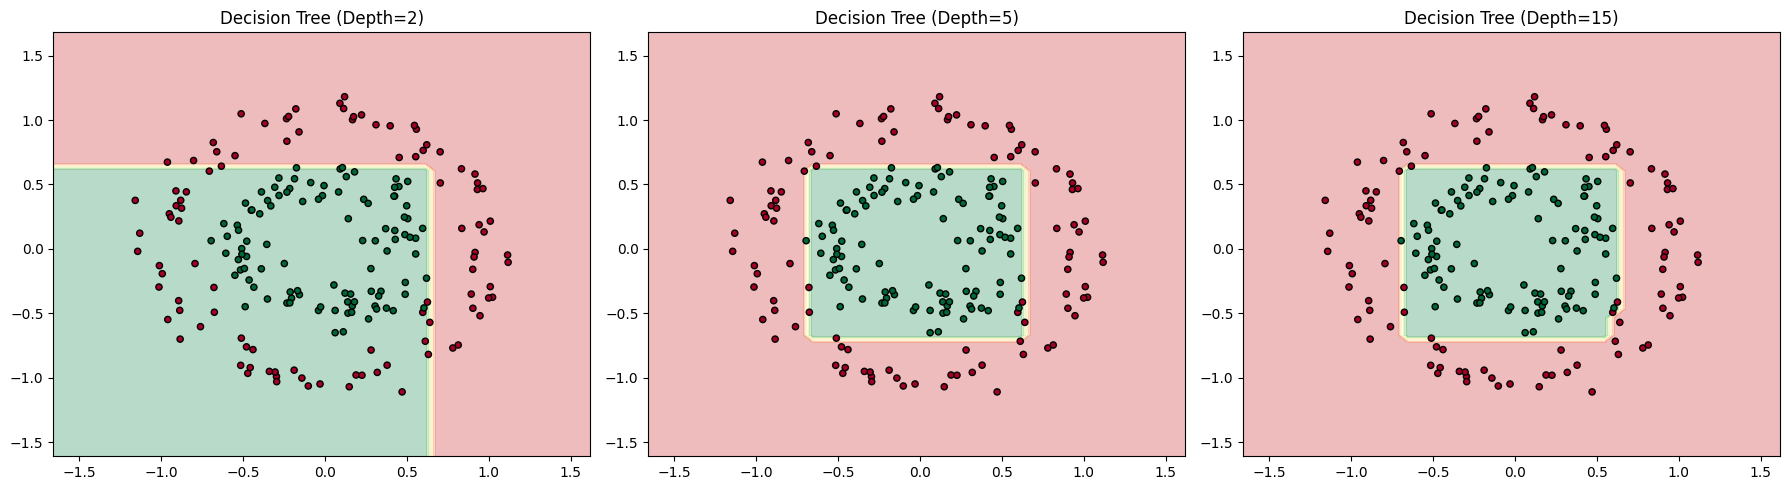

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlpackage.supervised_learning import DecisionTree
from sklearn.datasets import make_circles

# 1. Generate Non-Linear Data (Circles)
X, y = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# 2. Compare different depths
depths = [2, 5, 15]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, depth in enumerate(depths):
    # Note: Use small min_samples_split for deeper trees to see the effect
    model = DecisionTree(max_depth=depth, min_samples_split=2)
    model.fit(X, y)
    
    # Create Meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50))
    
    # Predict over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot
    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    axes[i].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='RdYlGn')
    axes[i].set_title(f'Decision Tree (Depth={depth})')

plt.tight_layout()
plt.show()